<a href="https://colab.research.google.com/github/Shruti-Asgekar/Deep-Learning-Lab/blob/main/DS48_LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPERIMENT NO: 5

NAME: Shruti Ghananeel Asgekar

PRN: 2324000901

TY-DS48

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

In [2]:
# 1. Load a dataset (e.g., MNIST)
print("Loading MNIST dataset...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# 2. Preprocess the data
# Reshape images to add a channel dimension (for grayscale, it's 1)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [4]:
# 3. Define the CNN model
print("Defining CNN model...")
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes for MNIST
])

Defining CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 4. Compile the model
print("Compiling model...")
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()

Compiling model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 5. Train the model
print("Training model... (This may take a few minutes)")
history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Training model... (This may take a few minutes)
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.9511 - loss: 0.1564 - val_accuracy: 0.9861 - val_loss: 0.0446
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 75s 20ms/step - accuracy: 0.9846 - loss: 0.0482 - val_accuracy: 0.9865 - val_loss: 0.0412
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9888 - loss: 0.0352 - val_accuracy: 0.9902 - val_loss: 0.0304
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9910 - loss: 0.0279 - val_accuracy: 0.9907 - val_loss: 0.0278
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9937 - loss: 0.0204 - val_accuracy: 0.9874 - val_loss: 0.0423


In [7]:
# 6. Evaluate the model
print("Evaluating model...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc}')

Evaluating model...
313/313 - 2s - 6ms/step - accuracy: 0.9874 - loss: 0.0423

Test accuracy: 0.9873999953269958


Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
CIFAR-10 training images shape: (50000, 32, 32, 3)
CIFAR-10 test images shape: (10000, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


Training CIFAR-10 CNN model... (This may take a few minutes)
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 32ms/step - accuracy: 0.4450 - loss: 1.5227 - val_accuracy: 0.5384 - val_loss: 1.2809
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.5853 - loss: 1.1662 - val_accuracy: 0.6187 - val_loss: 1.0810
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.6403 - loss: 1.0228 - val_accuracy: 0.6448 - val_loss: 1.0004
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.6720 - loss: 0.9324 - val_accuracy: 0.6663 - val_loss: 0.9428
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6995 - loss: 0.8594 - val_accuracy: 0.6728 - val_loss: 0.9541
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.7177 - loss: 0.8039 - val_accuracy: 0.6838 - val_loss: 0.9130
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.7322 - loss: 0.7594 - val_accuracy: 0.6935 - val_loss: 0.8917
Epoch 8/10
156

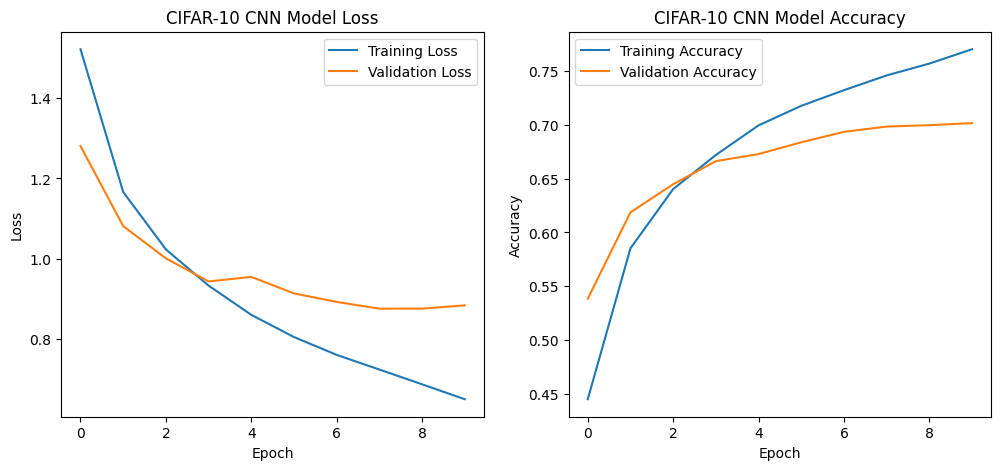


To perform comparative analysis with an ANN CIFAR model, please provide the ANN model's accuracy.
Current CNN CIFAR-10 Accuracy: 0.7016000151634216


In [8]:
import matplotlib.pyplot as plt

# (a) Load and Normalize CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(cifar_train_images, cifar_train_labels), (cifar_test_images, cifar_test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
cifar_train_images = cifar_train_images / 255.0
cifar_test_images = cifar_test_images / 255.0

print(f"CIFAR-10 training images shape: {cifar_train_images.shape}")
print(f"CIFAR-10 test images shape: {cifar_test_images.shape}")

# (b) Build Convolution Neural Network model with 3x3 filter and Maxpooling of 2x2 layer
cifar_cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes for CIFAR-10
])

cifar_cnn_model.summary()

# Compile the model
cifar_cnn_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Train the model
print("\nTraining CIFAR-10 CNN model... (This may take a few minutes)")
cifar_history = cifar_cnn_model.fit(cifar_train_images, cifar_train_labels, epochs=10,
                                      validation_data=(cifar_test_images, cifar_test_labels))

# (c) Evaluate Model performance
print("\nEvaluating CIFAR-10 CNN model...")
cifar_test_loss, cifar_test_acc = cifar_cnn_model.evaluate(cifar_test_images, cifar_test_labels, verbose=2)
print(f'\nCIFAR-10 CNN Test accuracy: {cifar_test_acc}')

# (d) Predict for test data
print("\nMaking predictions for CIFAR-10 test data...")
cifar_predictions = cifar_cnn_model.predict(cifar_test_images)
cifar_predicted_labels = np.argmax(cifar_predictions, axis=1)

# Display some predictions (optional)
print(f"First 5 true labels: {cifar_test_labels[:5].flatten()}")
print(f"First 5 predicted labels: {cifar_predicted_labels[:5]}")

# (e) Visualize using validation loss, actual loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cifar_history.history['loss'], label='Training Loss')
plt.plot(cifar_history.history['val_loss'], label='Validation Loss')
plt.title('CIFAR-10 CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# (f) Plot dataset values for Actual Accuracy and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(cifar_history.history['accuracy'], label='Training Accuracy')
plt.plot(cifar_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CIFAR-10 CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# (g) Perform comparative analysis using bar chart for ANN CIFAR model and CNN CIFAR model for accuracy score.
# Note: This requires an ANN CIFAR model to be defined and trained separately for a direct comparison.
# For now, we will just use the CNN accuracy. If you provide an ANN model's accuracy, I can plot it.

# Placeholder for ANN accuracy if available
# ann_cifar_accuracy = 0.45 # Example ANN accuracy

# If you have an ANN accuracy, uncomment and use the following:
# if 'ann_cifar_accuracy' in locals():
#     labels = ['CNN CIFAR-10', 'ANN CIFAR-10']
#     accuracies = [cifar_test_acc, ann_cifar_accuracy]
#     plt.figure(figsize=(6, 5))
#     plt.bar(labels, accuracies, color=['blue', 'orange'])
#     plt.ylim(0, 1)
#     plt.ylabel('Accuracy')
#     plt.title('Comparative Analysis: CNN vs ANN on CIFAR-10')
#     plt.show()
# else:
print("\nTo perform comparative analysis with an ANN CIFAR model, please provide the ANN model's accuracy.")
print(f"Current CNN CIFAR-10 Accuracy: {cifar_test_acc}")

# Store CNN accuracy for potential future comparison
cifar_cnn_accuracy = cifar_test_acc